# FoodEx2 Terms — EDA & NLP Data Preparation

This notebook covers:
1. **EDA** — shape, nulls, distributions, text length, field coverage
2. **Text cleaning** — scope notes, common names, scientific names
3. **NLP corpus construction** — rich text per term for embedding/matching tasks

In [ ]:
# !pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 6.2 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.9 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 2.8 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 4.8 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 566.4 kB/s eta 0:00:0000:0100:01


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
pd.set_option('display.max_colwidth', 120)

df = pd.read_excel('foodHierarchy.xlsx')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (31382, 8)


,termCode,termExtendedName,termShortName,termScopeNote,scientificNames,commonNames,allFacets,status
0,A000A,Teff grain,NaN,"Cereal grains from the plant classified under the species Eragrostis tef (Zucc.) Trotter, commonly known as Teff gra...",Eragrostis tef (Zucc.) Trotter,Tef grain,A000A#F01.A059P$F02.A066Q$F27.A000A$F33.A0C4A,APPROVED
1,A000B,Finger millet grain,NaN,"Cereal grains from the plant classified under the species Eleusine coracana (L.) Gaertn subsp. coracan, commonly kno...",Eleusine coracana (L.) Gaertn subsp. coracan,African millet grain$Koracan,A000B#F01.A059N$F02.A066Q$F27.A000B$F33.A0C4A,APPROVED
2,A000D,Foxtail millet grain,NaN,"Cereal grains from the plant classified under the species Setaria italica (L.) P.Beauv., commonly known as Foxtail m...",Setaria italica (L.) P.Beauv.,Foxtail millet,A000D#F01.A059R$F02.A066Q$F27.A000D$F33.A0C4A,APPROVED


## 1. EDA

In [4]:
# --- Field coverage ---
coverage = pd.DataFrame({
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'coverage_%': (df.notna().mean() * 100).round(1)
})
display(coverage)

,non_null,null,coverage_%
termCode,31382,0,100.0
termExtendedName,31382,0,100.0
termShortName,1774,29608,5.7
termScopeNote,31369,13,100.0
scientificNames,25461,5921,81.1
commonNames,7489,23893,23.9
allFacets,31382,0,100.0
status,31382,0,100.0


In [5]:
# --- Status distribution ---
print('Status value counts:')
print(df['status'].value_counts())
print()
# --- termCode structure ---
print('Unique termCodes:', df['termCode'].nunique())
print('Duplicate termCodes:', df['termCode'].duplicated().sum())

Status value counts:
status
APPROVED    31382
Name: count, dtype: int64

Unique termCodes: 31382
Duplicate termCodes: 0


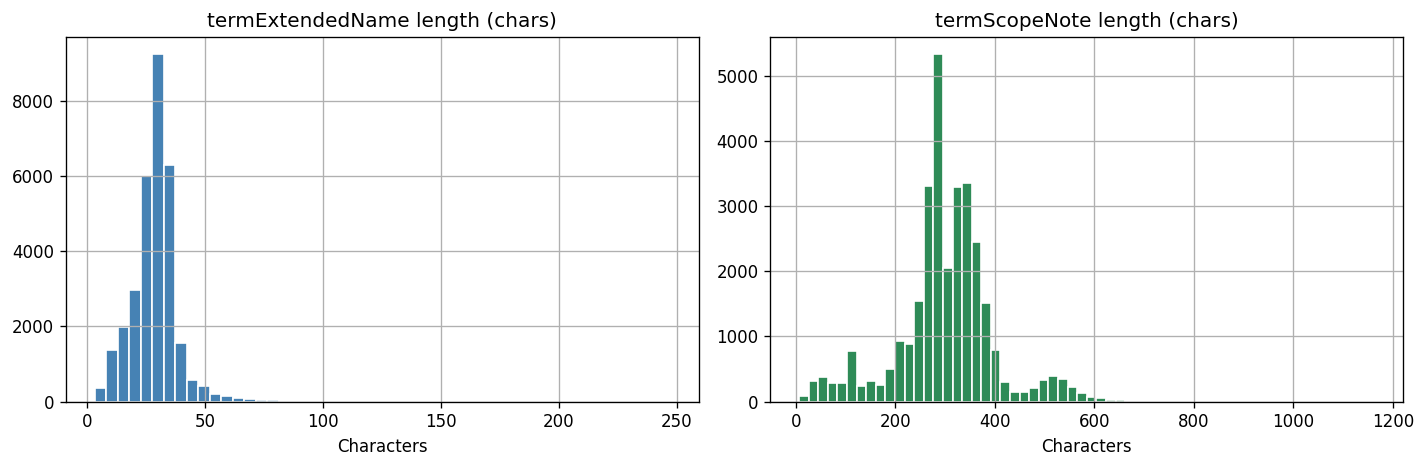


termExtendedName length stats:
count    31382.0
mean        28.8
std         10.4
min          3.0
25%         24.0
50%         29.0
75%         33.0
max        247.0
Name: name_len, dtype: float64

termScopeNote length stats:
count    31369.0
mean       302.8
std         99.8
min          7.0
25%        267.0
50%        297.0
75%        350.0
max       1163.0
Name: scope_len, dtype: float64


In [6]:
# --- Text length distributions ---
df['name_len'] = df['termExtendedName'].str.len()
df['scope_len'] = df['termScopeNote'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['name_len'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('termExtendedName length (chars)')
axes[0].set_xlabel('Characters')

df['scope_len'].dropna().hist(bins=60, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('termScopeNote length (chars)')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

print('\ntermExtendedName length stats:')
print(df['name_len'].describe().round(1))
print('\ntermScopeNote length stats:')
print(df['scope_len'].describe().round(1))

It is important to check the text length in terms of chars as: 
1. Token limits --> Models like BERT, sentence-transformers, etc. have a hard limit. Text that exceeds this gets silently truncated, so you need to know how many terms are affected and decide whether to truncate, chunk, or use a long-context model.

2. Detecting data quality issues
Very short text  often signals corrupt, placeholder, or missing data that won't train well. Very long text may contain noise (appended URLs, repeated boilerplate) that dilutes signal.

3. Choosing the right field for embedding
termExtendedName averages ~29 chars — great for a concise label. termScopeNote averages ~300 chars — better for semantic richness. Knowing the distribution helps you decide which field to use for which task (e.g. short name for entity matching, scope note for similarity search).

4. Batch size and memory planning
When encoding thousands of texts with GPU models, knowing the length distribution lets you set max_length and batch_size without OOM errors.

5. Imbalanced text richness
If some terms have 50 chars and others have 1,000 chars, their embeddings will have very different information density. You may want to normalize or truncate to a consistent window for fair comparison.

Char length is a cheap proxy for information content and model compatibility before you do any expensive processing.

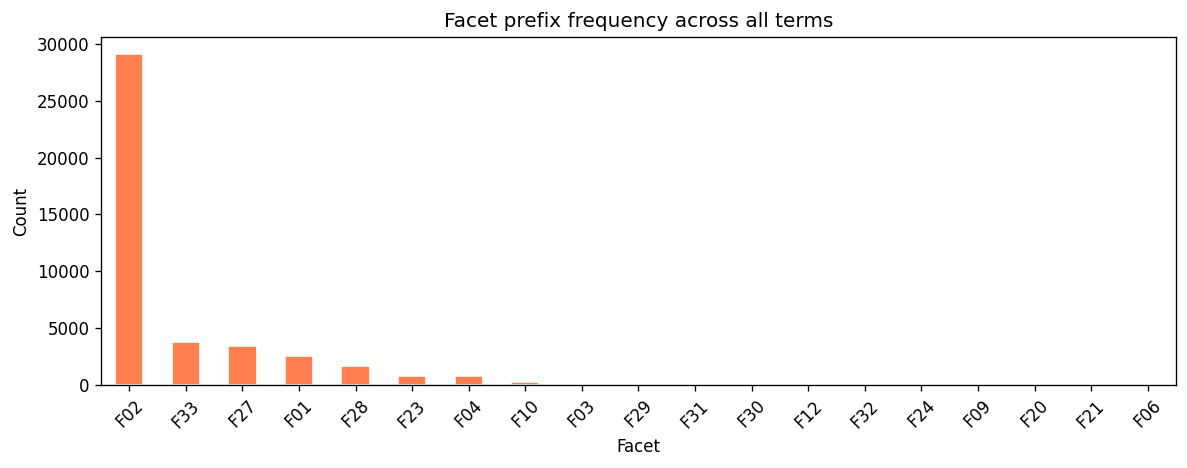

allFacets
F02    29132
F33     3807
F27     3458
F01     2584
F28     1670
F23      842
F04      796
F10      320
F03      117
F29       90
F31       68
F30       36
F12       33
F32       22
F24        5
F09        4
F20        3
F21        3
F06        1
Name: count, dtype: int64


In [7]:
# --- Facet prefix distribution ---
def extract_facets(allFacets):
    """Return list of facet codes (e.g. ['F01', 'F02']) from allFacets string."""
    if pd.isna(allFacets):
        return []
    parts = allFacets.split('#')
    if len(parts) < 2:
        return []
    return [f.split('.')[0] for f in parts[1].split('$') if f]

all_facets_flat = df['allFacets'].apply(extract_facets).explode()
facet_counts = all_facets_flat.value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
facet_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Facet prefix frequency across all terms')
ax.set_xlabel('Facet')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(facet_counts)

F02	highly represented: This facet describes the nature of the food item or the part of plant or animal it represents. The information brought by this facet is very often implicitly included in the food list groups. The descriptors are hierarchically structured in levels reflecting the natural relationship of terms. The list of descriptors is not designed to systematically include all possible parts or nature, but intends to cover all parts of plant or animal or the different nature types of food referred to in the food list.

In [9]:
# --- commonNames: how many terms have multiple names? ---
def count_common_names(val):
    if pd.isna(val):
        return 0
    return len(val.split('$'))

df['n_common_names'] = df['commonNames'].apply(count_common_names)
print('Common name count distribution:')
print(df['n_common_names'].value_counts().sort_index())

Common name count distribution:
n_common_names
0     23893
1      2780
2      3270
3      1074
4       298
5        30
6        10
7         7
8         8
9         2
10        4
11        1
12        1
14        1
15        1
17        1
18        1
Name: count, dtype: int64


For NLP food-matching tasks specifically, this matters because:

1. Training data augmentation
Each common name is a valid surface form for the same concept. "African millet grain" and "Koracan" both map to A000B. You can use them as positive pairs for contrastive learning or synonym expansion — but only if you know they exist.

2. Query-side coverage
Real-world food labels (from OpenFoodFacts, for example) use colloquial names, not the official FoodEx2 extended name. If 76% of terms have no common names, you know your matcher must rely heavily on the scope note description instead.

3. Disambiguation risk
A term with many common names is more likely to be ambiguous — the same common name might appear under multiple terms. Knowing which terms have 3+ names flags candidates where matching will be harder and where you may need ranking rather than direct lookup.

4. NLP text construction
When building the nlp_text field, common names go directly into the string. Knowing their distribution tells you how much they contribute to text length variance and whether they shift the token budget significantly for a subset of terms.

5. Evaluation set design
If you're building a benchmark for food name → FoodEx2 code matching, terms with multiple common names are natural test cases: you can test whether the model correctly maps an unseen alias to the right term code.

In [10]:
# --- Scope note structure: URLs embedded via '£' separator ---
print('Terms whose scopeNote contains URLs (£ separator):')
has_url = df['termScopeNote'].str.contains('£', na=False)
print(f'  {has_url.sum()} / {df.shape[0]} ({has_url.mean()*100:.1f}%)')

# Sample
df[has_url][['termCode','termExtendedName','termScopeNote']].head(3)

Terms whose scopeNote contains URLs (£ separator):
  28179 / 31382 (89.8%)


,termCode,termExtendedName,termScopeNote
0,A000A,Teff grain,"Cereal grains from the plant classified under the species Eragrostis tef (Zucc.) Trotter, commonly known as Teff gra..."
1,A000B,Finger millet grain,"Cereal grains from the plant classified under the species Eleusine coracana (L.) Gaertn subsp. coracan, commonly kno..."
2,A000D,Foxtail millet grain,"Cereal grains from the plant classified under the species Setaria italica (L.) P.Beauv., commonly known as Foxtail m..."


## 2. Text Cleaning

In [14]:
def clean_scope_note(text):
    """Strip URLs (after £) and normalize whitespace from a scope note."""
    if pd.isna(text):
        return ''
    # Remove everything after and including '£' (URLs section)
    text = text.split('£')[0]
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def parse_common_names(val):
    """Return list of common names split by '$'."""
    if pd.isna(val):
        return []
    return [n.strip() for n in val.split('$') if n.strip()]


def parse_scientific_names(val):
    """Return cleaned scientific name string."""
    if pd.isna(val):
        return ''
    return val.strip()


# Apply
df['scope_note_clean'] = df['termScopeNote'].apply(clean_scope_note)
df['common_names_list'] = df['commonNames'].apply(parse_common_names)
df['scientific_name_clean'] = df['scientificNames'].apply(parse_scientific_names)

# Verify
print('Scope note before/after cleaning:')
idx = df[df['termScopeNote'].str.contains('£', na=False)].index[0]
print('BEFORE:', df.loc[idx, 'termScopeNote'])
print('AFTER: ', df.loc[idx, 'scope_note_clean'])

Scope note before/after cleaning:
BEFORE: Cereal grains from the plant classified under the species Eragrostis tef (Zucc.) Trotter, commonly known as Teff grain or Tef grain. The part consumed/analysed is not specified. When relevant, information on the part consumed/analysed has to be reported with additional facet descriptors. In case of data collections related to legislations, the default part consumed/analysed is the one defined in the applicable legislation.£https://en.wikipedia.org/wiki/Teff£https://www.google.co.uk/search?tbm=isch&q=Teff
AFTER:  Cereal grains from the plant classified under the species Eragrostis tef (Zucc.) Trotter, commonly known as Teff grain or Tef grain. The part consumed/analysed is not specified. When relevant, information on the part consumed/analysed has to be reported with additional facet descriptors. In case of data collections related to legislations, the default part consumed/analysed is the one defined in the applicable legislation.


In [15]:
# Cleaned scope note length distribution
df['scope_clean_len'] = df['scope_note_clean'].str.len()

print('Cleaned scope note length stats:')
print(df['scope_clean_len'].describe().round(1))

print('\nTerms with very short scope note after cleaning (<20 chars):')
short = df[df['scope_clean_len'] < 20][['termCode','termExtendedName','scope_note_clean']]
print(short.shape[0])
display(short.head(10))

Cleaned scope note length stats:
count    31382.0
mean       202.8
std         84.7
min          0.0
25%        146.0
50%        198.0
75%        237.0
max       1054.0
Name: scope_clean_len, dtype: float64

Terms with very short scope note after cleaning (<20 chars):
44


,termCode,termExtendedName,scope_note_clean
4264,A06BF,Lactose (as part-nature),Lactose
5093,A07HG,Pan reheating,Reheating in a pan
5310,A07TD,Human food,Food for humans
5325,A07TV,Animal feed,Animal feed
5327,A07TY,Cattle feed,Feed for cattle
5329,A07VA,Game feed,Feed for game
5330,A07VB,Horse feed,Feed for horses
5332,A07VD,Poultry feed,Feed for poultry
5333,A07VE,Rabbit feed,Feed for rabbit
5337,A07VJ,Bird feed,Feed for pet birds


## 3. NLP Corpus Construction

Strategy: build one **rich text** string per term by concatenating all available text fields, deduplicated and separated clearly. This is suitable for:
- Sentence-transformer encoding
- BM25 / TF-IDF indexing
- Fine-tuning a food NER / matching model

In [17]:
def build_nlp_text(row):
    """
    Build a single rich-text string per FoodEx2 term.
    
    Format (fields concatenated in priority order):
        <termExtendedName>. [<termShortName>.] [<commonNames...>.] 
        [<scientificNames>.] <scope_note_clean>
    """
    parts = []

    # Primary name (always present)
    parts.append(row['termExtendedName'].strip())

    # Short name (rarely present, but useful alias)
    if pd.notna(row['termShortName']) and str(row['termShortName']).strip():
        parts.append(str(row['termShortName']).strip())

    # Common names
    if row['common_names_list']:
        parts.extend(row['common_names_list'])

    # Scientific name
    if row['scientific_name_clean']:
        parts.append(row['scientific_name_clean'])

    # Description (deduplicate against primary name)
    if row['scope_note_clean']:
        parts.append(row['scope_note_clean'])

    # Join all parts, ensuring each ends with a period
    text_parts = []
    for p in parts:
        p = p.strip().rstrip('.')
        if p:
            text_parts.append(p + '.')

    return ' '.join(text_parts)


df['nlp_text'] = df.apply(build_nlp_text, axis=1)

print('NLP text length stats:')
print(df['nlp_text'].str.len().describe().round(1))

# Show a few examples
for _, row in df.sample(3, random_state=7).iterrows():
    print(f"\n[{row['termCode']}] {row['termExtendedName']}")
    print(row['nlp_text'])

NLP text length stats:
count    31382.0
mean       262.6
std         97.0
min          8.0
25%        198.0
50%        252.0
75%        312.0
max       1270.0
Name: nlp_text, dtype: float64

[A0EFL] Fructose (feed)
Fructose (feed). Fructose as animal feed.

[A180K] Horned Lark (as animal)
Horned Lark (as animal). Shore Lark. Eremophila alpestris. Live animals of the taxonomic species Eremophila alpestris. The animals are commonly known as Horned Lark or Shore Lark. The part considered is by default the whole living organism.

[A0CAF] Fattening weaners to growers (as animal)
Fattening weaners to growers (as animal). Grown-up pigs for meat production (nowadays still relatively young, because pigs are usually not raised until complete adult maturity). The part considered is by default the whole living organism.


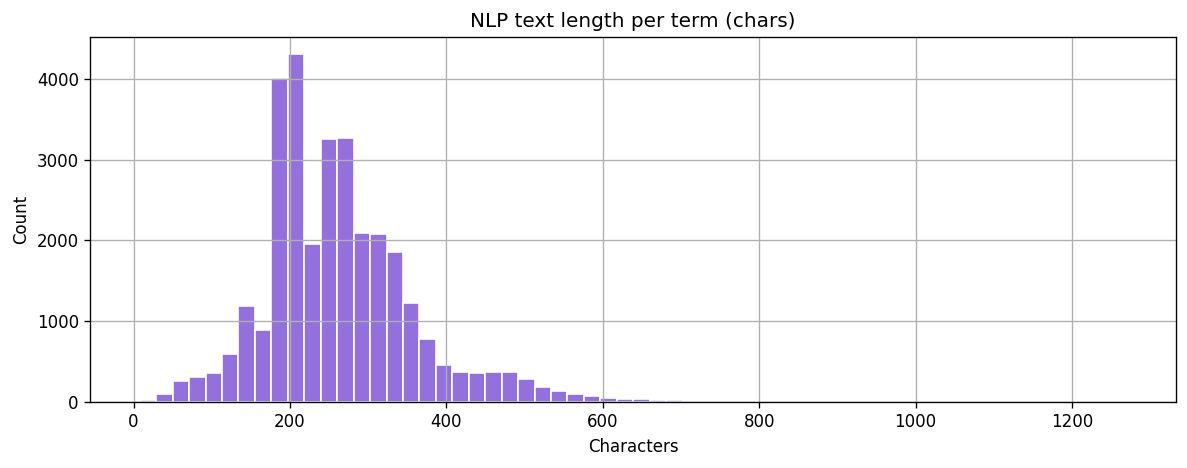

In [18]:
# --- NLP text length distribution ---
fig, ax = plt.subplots(figsize=(10, 4))
df['nlp_text'].str.len().hist(bins=60, ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('NLP text length per term (chars)')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [19]:
# --- Word count per term ---
df['nlp_word_count'] = df['nlp_text'].str.split().str.len()
print('Word count stats:')
print(df['nlp_word_count'].describe().round(1))

# Token budget check (for transformer models with 512 token limit)
# Rough estimate: 1 word ≈ 1.3 tokens
df['approx_tokens'] = (df['nlp_word_count'] * 1.3).round().astype(int)
over_512 = (df['approx_tokens'] > 512).sum()
print(f'\nTerms likely exceeding 512 tokens (~{over_512}, {over_512/len(df)*100:.1f}%)')
print('-> These may need truncation when passed to transformers.')

Word count stats:
count    31382.0
mean        38.2
std         14.1
min          1.0
25%         28.0
50%         36.0
75%         46.0
max        167.0
Name: nlp_word_count, dtype: float64

Terms likely exceeding 512 tokens (~0, 0.0%)
-> These may need truncation when passed to transformers.


## 4. Export NLP-ready Dataset

In [20]:
# --- Build final NLP-ready dataframe ---
nlp_df = df[[
    'termCode',
    'termExtendedName',
    'termShortName',
    'common_names_list',
    'scientific_name_clean',
    'scope_note_clean',
    'allFacets',
    'nlp_text',
    'nlp_word_count',
]].copy()

# Explode common names to a flat string for CSV-friendliness
nlp_df['common_names'] = nlp_df['common_names_list'].apply(lambda x: ' | '.join(x))
nlp_df = nlp_df.drop(columns=['common_names_list'])

print(f'Final dataset shape: {nlp_df.shape}')
display(nlp_df.head(3))

# Save
nlp_df.to_csv('foodex2_nlp.csv', index=False)
print('\nSaved to foodex2_nlp.csv')

Final dataset shape: (31382, 9)


,termCode,termExtendedName,termShortName,scientific_name_clean,scope_note_clean,allFacets,nlp_text,nlp_word_count,common_names
0,A000A,Teff grain,NaN,Eragrostis tef (Zucc.) Trotter,"Cereal grains from the plant classified under the species Eragrostis tef (Zucc.) Trotter, commonly known as Teff gra...",A000A#F01.A059P$F02.A066Q$F27.A000A$F33.A0C4A,Teff grain. Tef grain. Eragrostis tef (Zucc.) Trotter. Cereal grains from the plant classified under the species Era...,70,Tef grain
1,A000B,Finger millet grain,NaN,Eleusine coracana (L.) Gaertn subsp. coracan,"Cereal grains from the plant classified under the species Eleusine coracana (L.) Gaertn subsp. coracan, commonly kno...",A000B#F01.A059N$F02.A066Q$F27.A000B$F33.A0C4A,Finger millet grain. African millet grain. Koracan. Eleusine coracana (L.) Gaertn subsp. coracan. Cereal grains from...,81,African millet grain | Koracan
2,A000D,Foxtail millet grain,NaN,Setaria italica (L.) P.Beauv.,"Cereal grains from the plant classified under the species Setaria italica (L.) P.Beauv., commonly known as Foxtail m...",A000D#F01.A059R$F02.A066Q$F27.A000D$F33.A0C4A,Foxtail millet grain. Foxtail millet. Setaria italica (L.) P.Beauv. Cereal grains from the plant classified under th...,72,Foxtail millet



Saved to foodex2_nlp.csv


In [21]:
# --- Summary ---
print('=== EDA SUMMARY ===')
print(f'Total terms:             {len(df):,}')
print(f'All APPROVED status:     yes')
print(f'Unique termCodes:        {df["termCode"].nunique():,}')
print()
print('Field coverage:')
print(f'  termExtendedName:      100%  (primary label)')
print(f'  termScopeNote:         {df["termScopeNote"].notna().mean()*100:.1f}%  (description, ~300 chars avg)')
print(f'  scientificNames:       {df["scientificNames"].notna().mean()*100:.1f}%')
print(f'  commonNames:           {df["commonNames"].notna().mean()*100:.1f}%  (split by "$")')
print(f'  termShortName:         {df["termShortName"].notna().mean()*100:.1f}%')
print()
print('Scope note cleaning:')
print(f'  Had embedded URLs:     {df["termScopeNote"].str.contains("£", na=False).mean()*100:.1f}%')
print(f'  Separator used:        £  (text £ url1 £ url2...)')
print()
print('NLP corpus:')
print(f'  Avg words per term:    {df["nlp_word_count"].mean():.0f}')
print(f'  Terms > 512 tokens:    {over_512:,} ({over_512/len(df)*100:.1f}%)')
print()
print('Dominant facets: F02 (Part), F33 (Process), F27 (RACsource), F01 (Source)')

=== EDA SUMMARY ===
Total terms:             31,382
All APPROVED status:     yes
Unique termCodes:        31,382

Field coverage:
  termExtendedName:      100%  (primary label)
  termScopeNote:         100.0%  (description, ~300 chars avg)
  scientificNames:       81.1%
  commonNames:           23.9%  (split by "$")
  termShortName:         5.7%

Scope note cleaning:
  Had embedded URLs:     89.8%
  Separator used:        £  (text £ url1 £ url2...)

NLP corpus:
  Avg words per term:    38
  Terms > 512 tokens:    0 (0.0%)

Dominant facets: F02 (Part), F33 (Process), F27 (RACsource), F01 (Source)
